<a href="https://colab.research.google.com/github/sanyukta1403/Climate-and-Big-Data/blob/main/CMIP6_map_example_im_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Plotting Global Maps

Marinov et al. Climate and Big Data Class @ Penn, spring 2026.  Produced initially by Sergey M., updated by im and lm in Feb 2026

This notebook will show you how to plot global maps in a CMIP6 generation climate model, as well as do averages and some other operations with *xarrays*, a data structure we will use throughout the semester.

In [ ]:
# imports all the pakages needed to run this code
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import detrend
import pandas as pd
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis fsspec
import xarray as xr; xr.set_options(display_style='html')

import gcsfs
import zarr

!pip install cartopy
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

### Loading data with xarray

In [ ]:
# select CMIP6 dataset. Here we are getting CMIP6 data from a googleapi

data = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
data = data.query("member_id == 'r1i1p1f1' & activity_id == 'CMIP' and table_id == 'Omon' and variable_id == 'tos' and experiment_id == 'historical'")
data = data.query("institution_id == 'NCAR' and source_id == 'CESM2' and version == 20190308 and grid_label=='gr'")
data
# this is the datafile we want to open. It can be in formats such
# as .nc (netCDF),.h5 (HDF5),.grb (GRIB), or others that xarray supports.
# Note that this dataset covers the period 185001 (Jan 1850) to 201412 (Dec 2014)
# r1i1p1f1 = the first ensemble member ran
# CMIP6 = is the latest generation of climate models
# CESM2 is the name of the NCAR model
# tos_Omon refers to surface temperature data on a monthly scale,
# the O refers to the ocean - as opposed to land or atmosphere - output
# historical refers to runs from 1850 to 2014
# v20190308 this is a particular version of the model, a note for the developers, we don't care about this

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
59298,CMIP,NCAR,CESM2,historical,r1i1p1f1,Omon,tos,gr,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r1...,NaN,20190308


In [ ]:
#THE PROCEDURE FOR READING FILES HERE Works on GoogleCollab but will NOT work on NCAR.
# on NCAR the gsfc commandm the xr.open_zarr will not be used.

# this only needs to be created once
gcs = gcsfs.GCSFileSystem(token='anon')

# get the path to a specific zarr store (the last one from the dataframe above)
zstore = data.zstore.values[0]

# create a mutable-mapping-style interface to the store
mapper = gcs.get_mapper(zstore)

# open it using xarray and zarr
df = xr.open_zarr(zstore, consolidated=True, storage_options={"token": "anon"})

# xr stands for the xarray. Command returns an xarray Dataset object, which is
# a collection of multi-dimensional arrays with labeled dimensions
# command is used in the xarray library in Python, which is commonly used
# for working with labeled multi-dimensional arrays (such as NetCDF, HDF5, and GRIB files).

In [ ]:
df  # this will list all the dimensions, attributes and variables inside the xarray object

<xarray.Dataset> Size: 513MB
Dimensions:    (lat: 180, d2: 2, lon: 360, time: 1980)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
    lat_bnds   (lat, d2) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    lon_bnds   (lon, d2) float64 6kB dask.array<chunksize=(360, 2), meta=np.ndarray>
  * time       (time) object 16kB 1850-01-15 12:59:59.999997 ... 2014-12-15 1...
    time_bnds  (time, d2) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Dimensions without coordinates: d2
Data variables:
    tos        (time, lat, lon) float32 513MB dask.array<chunksize=(385, 180, 360), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                15
    ...                     ...
    table_id:               Omon
    tracking_id:            hdl:21.14100/113dbe36-4603-4625-acac-b06ce9c86222
    variable_id:            tos
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r1i1p1f1
    status:                 2019-10-25;created;by nhn2@columbia.edu

In [ ]:
# print(df.variables) #list of variables inside df
print(df["tos"])  # access specific variable data and gives you info on this
# Variable. Note that tos= refers to temperature at the ocean surface

<xarray.DataArray 'tos' (time: 1980, lat: 180, lon: 360)> Size: 513MB
dask.array<open_dataset-tos, shape=(1980, 180, 360), dtype=float32, chunksize=(385, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) object 16kB 1850-01-15 12:59:59.999997 ... 2014-12-15 12:...
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos


### Filtering and operations with xarray

In [ ]:
ds = df.sel(time=slice("1995", "2014"))
# this is how you select a subset of data based on specific range of values
# along a particular dimension. In this case, the time dimension.

In [ ]:
ds_mean = ds["tos"].mean(dim="time", skipna=1)  #
ds_mean
# This averages over all time steps in ds (here 1991 to 2010) for each spatial location
# Note that this gives you a new data array where the time dimension is reduced
# (collapsed) and you will have the average sea surface temp for each spatial
# grid point (lat and longitude). Since you have averaged across time, time will be eliminated

# Note that you could average over latitude or longitude instead, which would
# collapse that specific dimension

# The skipna=1 argument ensures that any missing or NaN (Not a Number) values are ignored during
# the mean computation, so they don't affect the result.
# If instead you set skipna=False (or skipna=0), then the mean will be computed
# considering NaN values, and if there is any NaN in the time slice for a
# particular location, the result will also be NaN for that location.
# This is not always a bad thing, and it will depend on what your goal is

<xarray.DataArray 'tos' (lat: 180, lon: 360)> Size: 259kB
dask.array<mean_agg-aggregate, shape=(180, 360), dtype=float32, chunksize=(180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

In [ ]:
# to check minimum max and mean values of data for plotting you can do this:
print(np.nanmin(ds_mean))
print(np.nanmax(ds_mean))
print(np.nanmean(ds_mean))

-1.8794903
31.351799
14.24552


### Plotting with cartopy

<xarray.DataArray 'lon' (lon: 360)> Size: 3kB
array([  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5])
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    axis:           X
    bounds:         lon_bnds
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east


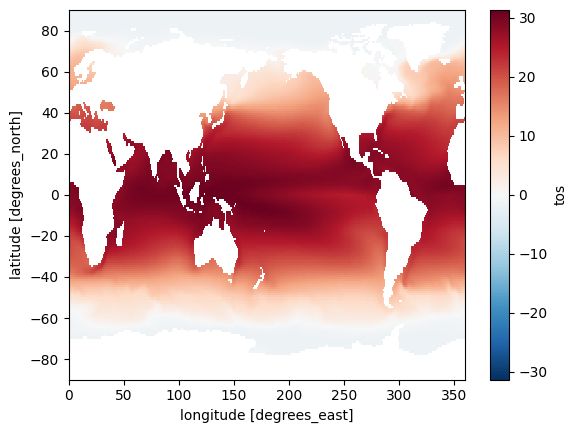

In [ ]:
# Cartopy is a Python library used for geospatial data visualization and map
# plotting. It is specifically designed to work with matplotlib for creating
# high-quality maps and visualizations of geographical data. Cartopy makes it
# easy to plot data on different types of map projections and overlays, such as
# adding coastlines, rivers, and country borders to your visualizations.
# It is well integrated with matplotlib and xarray

#THE QUICK AND DIRTY PLOTTING FIRST (NOT WHAT YOU WILL TURN IN FOR HWs)

Lon = ds_mean.lon
Lat = ds_mean.lat

print(ds_mean.lon)
# it gives you the array of longitude values that correspond to the lon dimension in ds_mean.

# s = ds_mean * 1000 #Unit conversion #for silica

# FIRST LET's try simple plotting:

ds_mean.plot()

In [ ]:
# A FANCIER PLOT THAT INCLUDES COLOR BAR, etc. This is the type of plot you want
#to create for your HOMEWORKSs

fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# add coastlines and borders
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, edgecolor="black")
ax.set_title("Temperature 1995-2014, Average SST [°C]", size=22, pad=10)

# set bounds of graph using min/max of data
levels = np.linspace(np.floor(np.nanmin(ds_mean)), np.ceil(np.nanmax(ds_mean)), 81)

# contour plot
contf = ax.contourf(Lon - 180, Lat, ds_mean, levels)

# We create a filled contour plot using Matplotlib.
# Contourf is typically used to visualize data that varies
# across a 2D space (such as geographic coordinates),
# where the color in the plot represents different values of the data.

# ds_mean is typically a 2D array or dataset containing the data values
# that you want to plot.

# levels defines the contour level thresholds, which need to be specified
# for us the levels is a list, so we define the exact contour levels
# if it specifies an integer, Matplotlib will automatically choose the level breaks

# Lon = x axis of the plot - represents the longitudes of your data (in degrees).
# The subtraction of 180 is done to shift the longitude range from the typical range of
# 0 to 360 degrees to -180 to 180 degrees. This is a common convention in
# geospatial data to represent longitudes in a way that centers the plot around the
# prime meridian (0° longitude). This makes things easier to plot on world maps.

# Lat = y axis of the plot - represents the latitudes of your data (in degrees),
# which typically range from -90 (South Pole)to 90 (North Pole).

# add colorbar and labels
colbar = plt.colorbar(contf, drawedges=True, aspect=12, shrink=0.7)
colbar.set_ticks(np.arange(-2, 33, 2))
colbar.set_label("T (°C)", size=18, labelpad=40, rotation=0)

# latitude and longitude labels
ax.set_yticks(np.arange(-60, 61, 30), crs=cartopy.crs.PlateCarree())
ax.set_ylabel("Latitude", fontsize=18)
ax.set_xticks(np.arange(0, 360, 60), crs=cartopy.crs.PlateCarree())
ax.set_xticklabels(np.arange(0, 360, 60))
ax.set_xlabel("Longitude", fontsize=18, labelpad=15)

# Show plot
plt.show()

NameError: name 'plt' is not defined

### Visualizing climate anomalies

Next we will plot anomalies for the year 1881 relative to the 1995-2014 mean.  We will change colormap to seismic to better represent the anomalies pattern.

In [ ]:
ds_1881 = df.sel(time=slice("1881", "1882"))
ds_1881 = ds_1881["tos"].mean(dim="time", skipna=1)

anom_np = ds_1881 - ds_mean
anom_np
# this should return an array with 180 latitude points and 360 longitude points

<xarray.DataArray 'tos' (lat: 180, lon: 360)> Size: 259kB
dask.array<sub, shape=(180, 360), dtype=float32, chunksize=(180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

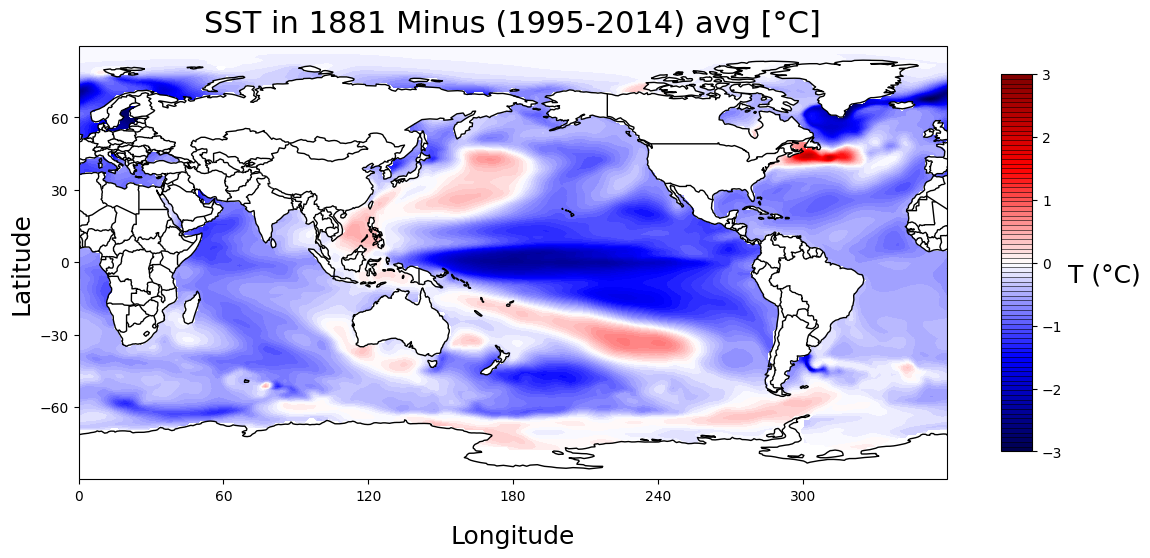

In [ ]:
# specifying a colormap for the anomaly map
cmap = mpl.cm.seismic
# Sets up a predefined Colormap in the Matplotlib library (cm module)
# seismic - usually used for data with positive values and negative values, to highlight
#   differences between positive and negative.
#   colormap will be centered around zero and have redish colors for positive values and
#   blueish colors for negative values.

levels = np.linspace(np.round(np.nanmin(anom_np)), np.round(np.nanmax(anom_np))+1, 81)
# we create new levels used for the contour function of temperature
# these values need to change if you will be plotting other variables in the future

fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
# This Creates a subplot with the PlateCarree projection,
# setting the central longitude to 180°W, which is in the middle of Pacific Ocean
# you could try if you wanted to set the central longitude to 0 degrees, and see how it changes

# add coastlines and borders and title
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, edgecolor="black")
ax.set_title("SST in 1881 Minus (1995-2014) avg [°C]", size=22, pad=10)

# contour plot
contf = ax.contourf(Lon - 180, Lat, anom_np, levels, cmap=cmap)

# Next: add colorbar and labels
colbar = plt.colorbar(contf, drawedges=True, aspect=12, shrink=0.7)
colbar.set_ticks(np.arange(-3, 4))
colbar.set_label("T (°C)", size=18, labelpad=30, rotation=0)

# latitude and longitude labels
ax.set_yticks(np.arange(-60, 61, 30), crs=cartopy.crs.PlateCarree())
ax.set_ylabel("Latitude", fontsize=18)
ax.set_xticks(np.arange(0, 360, 60), crs=cartopy.crs.PlateCarree())
ax.set_xticklabels(np.arange(0, 360, 60))
ax.set_xlabel("Longitude", fontsize=18, labelpad=15)

plt.show()
# What you can see here is that the SST in 1881 looked rather unusual compared to the 20 year
# modern average. At least in this model run, 1881 was a LaNina year, with
# strong Pacific upwelling that cools the tropical PAcific very strongly.
# On average 1881 was cooler than the present world, likely bc of climate change